# Modulo Biases

난수 생성 후, modulo 연산을 통해 accumlated summation을 통해 여러 숫자 중 하나를 뽑는 상황을 가정해보자.

<Axes: xlabel='value'>

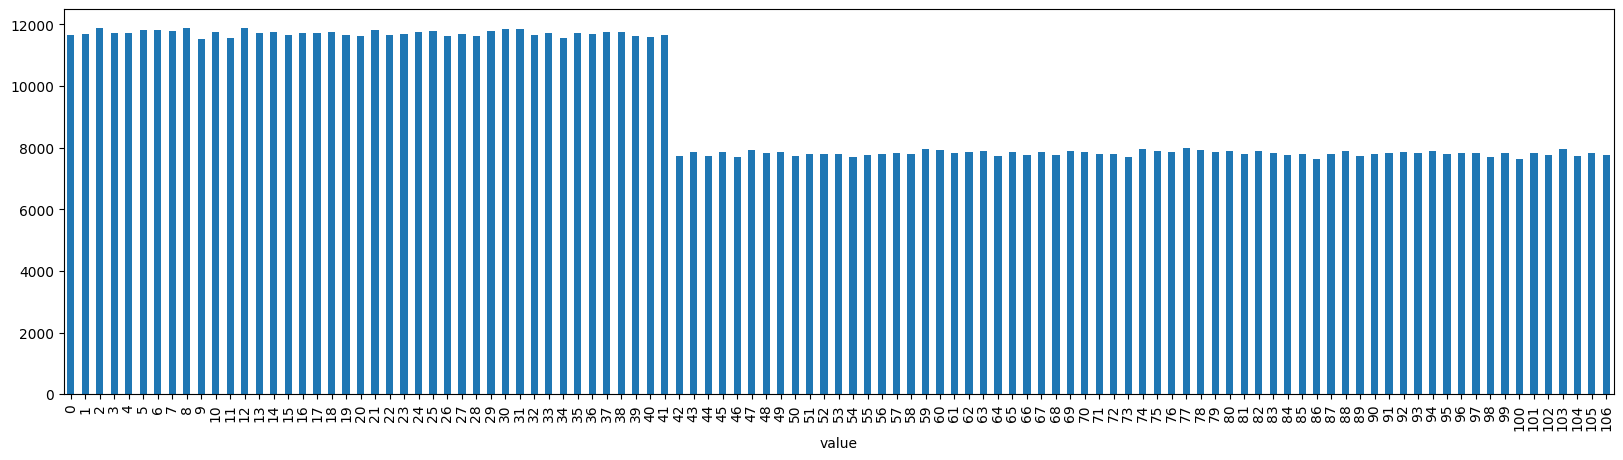

In [1]:
import os
import pandas

s = pandas.DataFrame({'value':[(x % 107) for x in os.urandom(1000000)]})
s['value'].value_counts().sort_index().plot(figsize=(20,5),kind='bar')

위와 같이 40 이후로는 bias가 일어나는 것을 볼 수 있다.

## 모듈로 연산의 대체

모듈로 연산을 대체하는 방법에는 rejection sampling이 있으나, rejection sampling은 bias가 없는 대신 유한시간 내에 연산이 끝나지 않을 수 있다는 단점이 있다. 이를 대체하기 위해서 Multiplication with right shitf라는 연산을 대신 사용할 수 있다.

### 구현

<Axes: xlabel='value'>

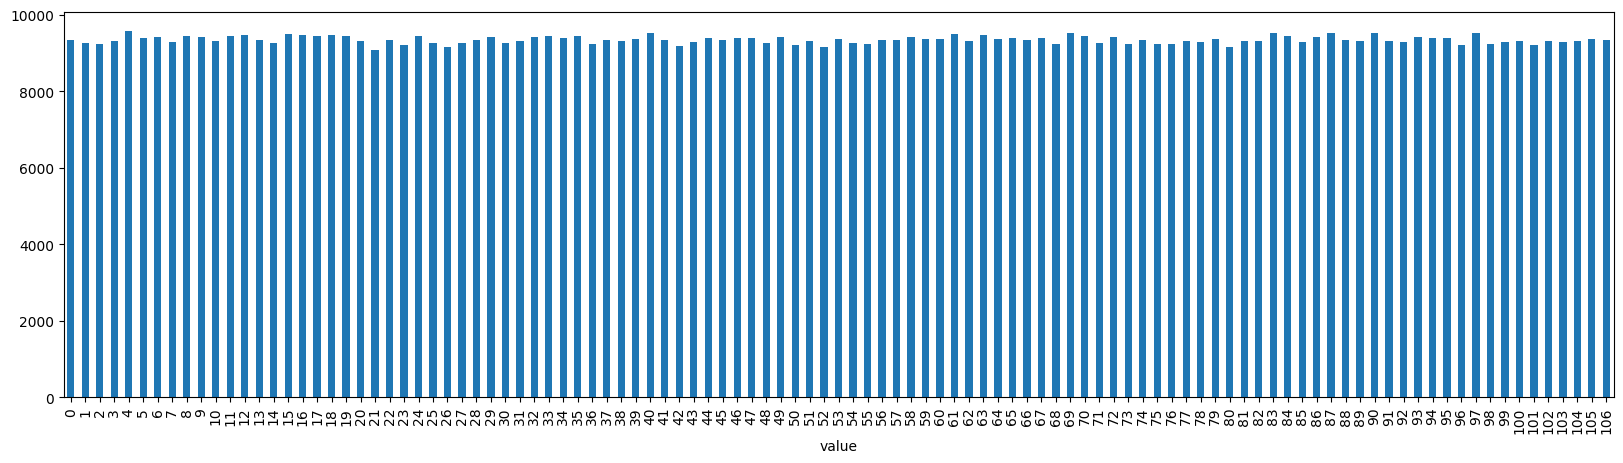

In [2]:
import random
import pandas as pd

values = {"value": []}
max_value = 107

for _ in range(1000000):
    x = random.getrandbits(15)
    values["value"].append((x * max_value) >> 15)

s = pd.DataFrame(values)
s['value'].value_counts().sort_index().plot(figsize=(20,5), kind='bar')